In [4]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [ ]:
#1. Imports
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from src.config import RESULTS_DIR

In [6]:
run_id = datetime.now().strftime("random_forest_%Y%m%d_%H%M%S")
run_dir = RESULTS_DIR / run_id
run_dir.mkdir(parents=True, exist_ok=True)

print("Saving Random Forest results to:", run_dir)

Saving Random Forest results to: E:\MIU\ML\Projects\ml-project\results\random_forest_20260531_094723


In [ ]:
# 2. Load preprocessed data
import numpy as np
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent
shared_run_dir = project_root / "results" / "shared_setup_20260531_094947"

X_train_ready = np.load(shared_run_dir / "X_train_ready.npy")
X_test_ready = np.load(shared_run_dir / "X_test_ready.npy")

y_train = pd.read_csv(shared_run_dir / "y_train.csv").squeeze()
y_test = pd.read_csv(shared_run_dir / "y_test.csv").squeeze()

feature_names_file = shared_run_dir / "feature_names.txt"

if feature_names_file.exists():
    feature_names = feature_names_file.read_text().splitlines()
else:
    feature_names = None

print(X_train_ready.shape)
print(X_test_ready.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 14)
(2000, 14)
(8000,)
(2000,)


In [19]:
#3. Baseline Random Forest Training & Evaluation
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ready, y_train)

y_pred = rf.predict(X_test_ready)
y_proba = rf.predict_proba(X_test_ready)[:, 1]

In [ ]:
#4. Baseline Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

[[1932    0]
 [   2   66]]
ROC AUC: 0.9910447874802095


In [21]:
#5. Balanced Random Forest
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train_ready, y_train)

y_pred_balanced = rf_balanced.predict(X_test_ready)
y_proba_balanced = rf_balanced.predict_proba(X_test_ready)[:,1]

In [22]:
#6. Balanced Random Forest Evaluation
print("Balanced Random Forest Evaluation:")
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))
print("ROC AUC:", roc_auc_score(y_test, y_proba_balanced))


Balanced Random Forest Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

[[1932    0]
 [   2   66]]
ROC AUC: 0.9839544513457557


In [23]:
#7. SMOTE + Random Forest
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_ready,
    y_train
)

rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote = rf_smote.predict(X_test_ready)
y_proba_smote = rf_smote.predict_proba(X_test_ready)[:,1]

In [24]:
#8. SMOTE Evaluation
print("SMOTE + Random Forest Evaluation:")
print(classification_report(y_test, y_pred_smote))
print(confusion_matrix(y_test, y_pred_smote))
print("ROC AUC:", roc_auc_score(y_test, y_proba_smote))


SMOTE + Random Forest Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

[[1932    0]
 [   2   66]]
ROC AUC: 0.9832846181951042


In [26]:
#9. Comparison Table
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

# Baseline RF
results.append({
    "model": "Random Forest Baseline",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
})

# Balanced RF
results.append({
    "model": "Random Forest Balanced",
    "accuracy": accuracy_score(y_test, y_pred_balanced),
    "precision": precision_score(y_test, y_pred_balanced),
    "recall": recall_score(y_test, y_pred_balanced),
    "f1": f1_score(y_test, y_pred_balanced),
    "roc_auc": roc_auc_score(y_test, y_proba_balanced)
})

# SMOTE RF
results.append({
    "model": "Random Forest + SMOTE",
    "accuracy": accuracy_score(y_test, y_pred_smote),
    "precision": precision_score(y_test, y_pred_smote),
    "recall": recall_score(y_test, y_pred_smote),
    "f1": f1_score(y_test, y_pred_smote),
    "roc_auc": roc_auc_score(y_test, y_proba_smote)
})

results_df = pd.DataFrame(results)

results_df

results_df.to_csv(run_dir / "random_forest_comparison.csv", index=False)
print("Saved comparison to:", run_dir)

Saved comparison to: E:\MIU\ML\Projects\ml-project\results\random_forest_20260531_094723


In [ ]:
#10. Feature Importance
import pandas as pd

# Use the best model
best_model = rf

importance_df = pd.DataFrame({
    "feature": feature_names if feature_names is not None else range(X_train_ready.shape[1]),
    "importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

importance_df.to_csv(
    run_dir / "feature_importance.csv",
    index=False
)

print("Saved feature importance")

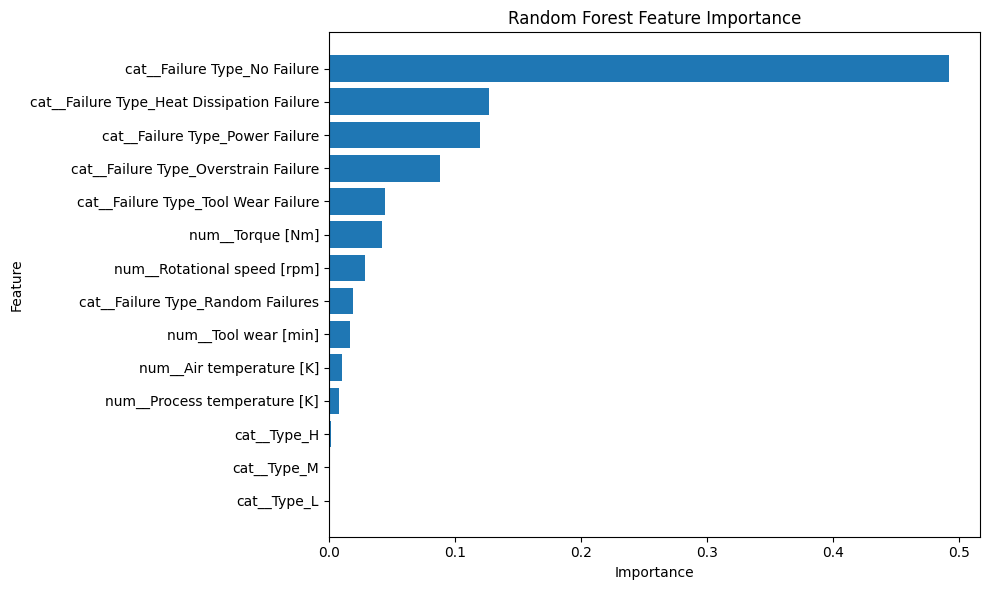

In [ ]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    run_dir / "random_forest_feature_importance.png",
    bbox_inches="tight"
)

plt.show()